# Residual Connections

**Dataset:** CIFAR-100 (100 classes, 32×32 images)

Adding more layers does not always help. Beyond a certain depth, plain networks get *worse* — even on training data.
This phenomenon is called the **degradation problem**: the network fails to learn identity mappings across many layers, so extra depth hurts instead of helping.

He et al. (2015) showed that a single structural change — adding an identity shortcut to each block — is enough to fix it.

In [1]:
import os
import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"PyTorch {torch.__version__}  |  device: {device}")

PyTorch 2.4.1  |  device: mps


In [2]:
# Monitor training curves live with TensorBoard.
# Run this cell once before (or during) training.
# %load_ext tensorboard
# %tensorboard --logdir tb_logs

---
## 0 — Shared Infrastructure


In [3]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
NUM_CLASSES  = 100
BATCH_SIZE   = 128
MAX_EPOCHS   = 50
LR           = 0.1  # SGD with cosine annealing
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 4   # adjust to the number of CPU cores available on your machine

# Channel-wise mean and std of CIFAR-100, computed on the training set.
# Used to normalise inputs to zero mean and unit variance per channel.
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

# All artefacts (data, checkpoints, logs) are stored inside this notebook folder.
DATA_DIR = os.path.join(os.getcwd(), "data")
CKPT_DIR = os.path.join(os.getcwd(), "saved_models")
LOG_DIR  = os.path.join(os.getcwd(), "tb_logs")


# ── Data ──────────────────────────────────────────────────────────────────────
class CIFAR100DataModule(pl.LightningDataModule):
    def __init__(self):
        super().__init__()

        # Training: random crop + horizontal flip for regularisation
        self.transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        ])
        # Evaluation: deterministic, no augmentation
        self.transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        ])

    def prepare_data(self):
        datasets.CIFAR100(DATA_DIR, train=True,  download=True)
        datasets.CIFAR100(DATA_DIR, train=False, download=True)

    def setup(self, stage=None):
        self.train_set = datasets.CIFAR100(DATA_DIR, train=True,  transform=self.transform_train)
        self.test_set = datasets.CIFAR100(DATA_DIR, train=False, transform=self.transform_test)

    def _loader(self, dataset, shuffle):
        return DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            num_workers=NUM_WORKERS,
            persistent_workers=(NUM_WORKERS > 0),
        )

    def train_dataloader(self):
        return self._loader(self.train_set, shuffle=True)

    def val_dataloader(self):
        return self._loader(self.test_set, shuffle=False)


# ── Lightning wrapper ─────────────────────────────────────────────────────────
# BaseLitModel is a shared training loop that all models in this notebook inherit.
# Subclasses only need to define self.model — the rest (loss, logging, optimiser)
# is handled here so each model section stays focused on the architecture.
class BaseLitModel(pl.LightningModule):
    def __init__(self, lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=MAX_EPOCHS):
        super().__init__()
        self.save_hyperparameters("lr", "weight_decay", "max_epochs")
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage):
        images, labels = batch
        logits = self(images)
        loss = self.criterion(logits, labels)
        acc = (logits.argmax(dim=1) == labels).float().mean() * 100
        self.log(f"{stage}/loss", loss, on_step=False, on_epoch=True)
        self.log(f"{stage}/acc",  acc,  on_step=False, on_epoch=True, prog_bar=(stage == "val"))
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
            self.parameters(),
            lr=self.hparams.lr,
            momentum=0.9,
            weight_decay=self.hparams.weight_decay,
        )
        # Cosine annealing: lr decays smoothly from LR to ~0 over MAX_EPOCHS,
        # avoiding the abrupt drops of step-based schedules.
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

    def on_train_start(self):
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n{'='*55}\n  {self.__class__.__name__}  |  {n:,} parameters\n{'='*55}\n")


# ── Training helper ───────────────────────────────────────────────────────────
def train_model(lit_model, experiment_name):
    ckpt = os.path.join(CKPT_DIR, f"{experiment_name}.ckpt")
    if os.path.exists(ckpt):
        print(f"Checkpoint found for '{experiment_name}' — skipping training.")
        return
    os.makedirs(CKPT_DIR, exist_ok=True)
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        logger=TensorBoardLogger(LOG_DIR, name=experiment_name),
        callbacks=[
            LearningRateMonitor("epoch"),
            ModelCheckpoint(
                monitor="val/acc", mode="max",
                filename="best-{epoch:02d}-{val/acc:.1f}",
                save_top_k=1,
            ),
        ],
        enable_progress_bar=True,
    )
    trainer.fit(lit_model, datamodule=CIFAR100DataModule())
    trainer.save_checkpoint(ckpt)


# ── TensorBoard log reader ────────────────────────────────────────────────────
def load_scalars(experiment):
    results = {}
    pattern = os.path.join(LOG_DIR, experiment, "version_*")
    for version_dir in sorted(glob.glob(pattern)):
        ea = EventAccumulator(version_dir)
        ea.Reload()
        for tag in ea.Tags().get("scalars", []):
            results[tag] = [e.value for e in ea.Scalars(tag)]
    return results


print("Infrastructure ready.")

Infrastructure ready.


Files already downloaded and verified
Files already downloaded and verified


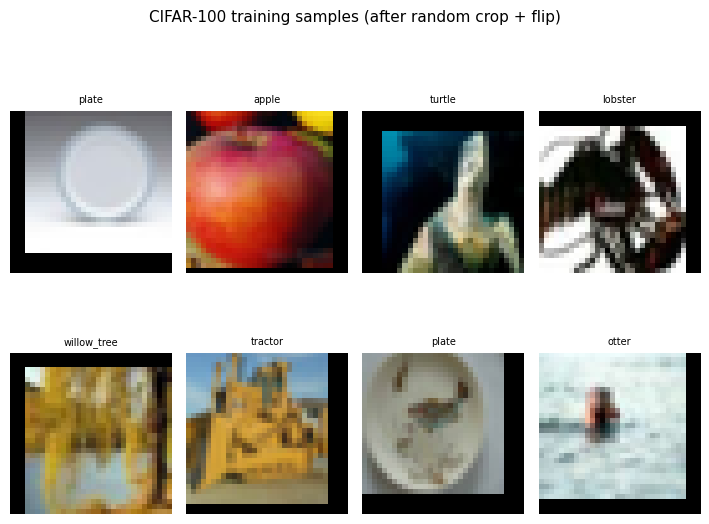

In [4]:
# Show a random batch of training images.
# Images are denormalised before display so colours look natural.
dm = CIFAR100DataModule()
dm.prepare_data()
dm.setup()

images, labels = next(iter(dm.train_dataloader()))

# Reverse the normalisation: pixel = std * normalised + mean
mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
std  = torch.tensor(CIFAR100_STD).view(3, 1, 1)
images_display = (images * std + mean).clamp(0, 1)

# CIFAR-100 class names (20 superclasses × 5 fine classes, alphabetical order)
CIFAR100_CLASSES = dm.train_set.classes

N = 8  # number of images to show
fig, axes = plt.subplots(2, N // 2, figsize=(N * 0.9, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_display[i].permute(1, 2, 0).numpy())
    ax.set_title(CIFAR100_CLASSES[labels[i]], fontsize=7)
    ax.axis("off")
plt.suptitle("CIFAR-100 training samples (after random crop + flip)", fontsize=11)
plt.tight_layout()
plt.show()

---
## 1 — Baseline: SimpleCNN

Three conv layers → global average pool → linear head.


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3×32×32 → 32×16×16
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2: 32×16×16 → 64×8×8
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3: 64×8×8 → 128×1×1
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            # Global average pooling: collapses each feature map to a single value,
            # making the classifier independent of the spatial resolution of the input.
            nn.AdaptiveAvgPool2d(output_size=1),
        )
        self.classifier = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # (B, 128, 1, 1) → (B, 128)
        return self.classifier(x)


class LitSimpleCNN(BaseLitModel):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.model = SimpleCNN()


train_model(LitSimpleCNN(lr=0.01), "01_simple_cnn")

Checkpoint found for '01_simple_cnn' — skipping training.


---
## 2 — Plain Deep Networks: The Degradation Problem

Same building block stacked to 20 or 56 layers — no skip connections.

Plain-56 performs *worse* than Plain-20, and both cases show degraded accuracy even on **training data**.
This is not overfitting: the 56-layer network has more capacity, yet it learns less.
Intuitively, an optimal deep model could always recover a shallower solution by setting the extra layers to identity maps — but in practice, plain networks struggle to learn this through gradient descent.

In [6]:
class PlainBlock(nn.Module):
    # Two Conv-BN-ReLU layers in sequence. No shortcut.
    # When stride=2 the first conv halves the spatial resolution.
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # First conv: may downsample spatially (stride) and change channel count
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        # Second conv: stride=1, preserves spatial size and channel count
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x


class PlainDeepNet(nn.Module):
    # n=3 → 20 layers 
    # n=9 → 56 layers 
    # Identical stage structure to ResNet for a fair comparison.
    def __init__(self, n=3):
        super().__init__()
        # Stem: 3×32×32 → 16×32×32
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        # Stage 1: 16 channels, 32×32
        self.stage1 = self._make_stage(in_ch=16, out_ch=16, n=n, stride=1)
        # Stage 2: 32 channels, 16×16 (first block downsamples)
        self.stage2 = self._make_stage(in_ch=16, out_ch=32, n=n, stride=2)
        # Stage 3: 64 channels, 8×8 (first block downsamples)
        self.stage3 = self._make_stage(in_ch=32, out_ch=64, n=n, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.fc   = nn.Linear(64, NUM_CLASSES)

    def _make_stage(self, in_ch, out_ch, n, stride):
        # First block handles the channel/spatial transition
        blocks = [PlainBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n):
            blocks.append(PlainBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class LitPlainNet(BaseLitModel):
    def __init__(self, n=3, **kwargs):
        super().__init__(**kwargs)
        self.save_hyperparameters("n")
        self.model = PlainDeepNet(n=n)


train_model(LitPlainNet(n=3), "03_plain_20")
train_model(LitPlainNet(n=9), "03_plain_56")


Checkpoint found for '03_plain_20' — skipping training.
Checkpoint found for '03_plain_56' — skipping training.


---
## 3 — ResNet: The Skip Connection Fix

The only code change from `PlainBlock`: `out = out + shortcut(x)` before the final ReLU.

$$\text{output} = \text{ReLU}\bigl(F(x) + x\bigr)$$

Each block now learns the **residual** $F(x) = H(x) - x$ rather than the full mapping $H(x)$.
If the optimal transformation is the identity, $F(x) = 0$ — easy to learn by pushing weights to zero.


In [7]:
class ResidualBlock(nn.Module):
    # Same as PlainBlock with one addition: out = out + shortcut(x).
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # Main path: same two convs as PlainBlock
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # Shortcut path: identity when shapes match, 1×1 conv when they don't.
        # A shape mismatch occurs at the first block of each stage
        # (stride=2 halves spatial size, or channel count changes).
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)         # save input (possibly projected) before transformation

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))     # no ReLU yet — add the shortcut first

        out = out + identity                # skip connection — the only difference from PlainBlock
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    # n=3 → ResNet-20 (~274k params)
    # n=9 → ResNet-56 (~856k params)
    # Identical stage structure to PlainDeepNet — only the block type differs.
    def __init__(self, n=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.stage1 = self._make_stage(in_ch=16, out_ch=16, n=n, stride=1)
        self.stage2 = self._make_stage(in_ch=16, out_ch=32, n=n, stride=2)
        self.stage3 = self._make_stage(in_ch=32, out_ch=64, n=n, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.fc   = nn.Linear(64, NUM_CLASSES)

    def _make_stage(self, in_ch, out_ch, n, stride):
        blocks = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n):
            blocks.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class LitResNet(BaseLitModel):
    def __init__(self, n=3, **kwargs):
        super().__init__(**kwargs)
        self.save_hyperparameters("n")
        self.model = ResNet(n=n)


train_model(LitResNet(n=3), "04_resnet_20")
train_model(LitResNet(n=9), "04_resnet_56")


Checkpoint found for '04_resnet_20' — skipping training.
Checkpoint found for '04_resnet_56' — skipping training.


---
## 4 — Results


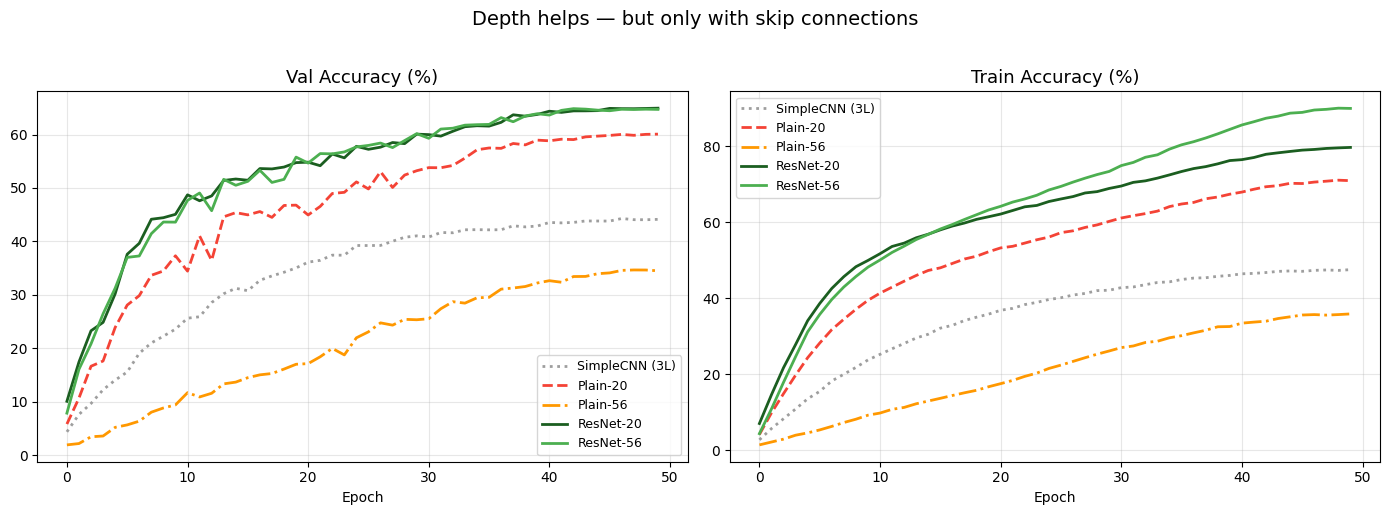

In [8]:
EXPERIMENTS = {
    "01_simple_cnn": {"label": "SimpleCNN (3L)", "color": "#9E9E9E", "ls": ":"},
    "03_plain_20":   {"label": "Plain-20",        "color": "#F44336", "ls": "--"},
    "03_plain_56":   {"label": "Plain-56",        "color": "#FF9800", "ls": "-."},
    "04_resnet_20":  {"label": "ResNet-20",       "color": "#1B5E20", "ls": "-"},
    "04_resnet_56":  {"label": "ResNet-56",       "color": "#4CAF50", "ls": "-"},
}

all_data = {exp: load_scalars(exp) for exp in EXPERIMENTS}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp, style in EXPERIMENTS.items():
    for ax, tag in [(axes[0], "val/acc"), (axes[1], "train/acc")]:
        vals = all_data[exp].get(tag, [])
        if vals:
            ax.plot(vals, color=style["color"], linestyle=style["ls"],
                    linewidth=2, label=style["label"])

for ax, title in zip(axes, ["Val Accuracy (%)", "Train Accuracy (%)"]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Depth helps — but only with skip connections", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
param_counts = {
    "01_simple_cnn": sum(p.numel() for p in SimpleCNN().parameters()),
    "03_plain_20":   sum(p.numel() for p in PlainDeepNet(n=3).parameters()),
    "03_plain_56":   sum(p.numel() for p in PlainDeepNet(n=9).parameters()),
    "04_resnet_20":  sum(p.numel() for p in ResNet(n=3).parameters()),
    "04_resnet_56":  sum(p.numel() for p in ResNet(n=9).parameters()),
}

print(f"{'Model':<18} {'Best val acc':>13} {'Final train acc':>16} {'Params':>10}")
print("-" * 62)
for exp, style in EXPERIMENTS.items():
    best_val    = max(all_data[exp].get("val/acc",   [float("nan")]))
    final_train = all_data[exp].get("train/acc", [float("nan")])[-1]
    n_params    = param_counts[exp]
    print(f"{style['label']:<18} {best_val:>13.1f} {final_train:>16.1f} {n_params:>10,}")


Model               Best val acc  Final train acc     Params
--------------------------------------------------------------
SimpleCNN (3L)              44.3             47.5    106,148
Plain-20                    60.1             70.9    275,572
Plain-56                    34.7             35.9    858,868
ResNet-20                   64.9             79.7    278,324
ResNet-56                   64.8             89.9    861,620
